In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import wilcoxon
import itertools
import sys
curr_dir = os.getcwd()
ROOT_DIR = os.path.abspath(os.path.join(curr_dir, os.pardir, os.pardir))
if ROOT_DIR not in sys.path:
    sys.path.append(ROOT_DIR)
import liset_tk.lists_sessions as lists_sessions
# Set style
sns.set_style("whitegrid")
# plt.rcParams.update({'font.size': 12})
plt.rcParams['svg.fonttype'] = 'none'

In [2]:
# Load Data
results_path = os.path.join("spikes", "all_networks_metrics.csv")

if os.path.exists(results_path):
    df = pd.read_csv(results_path)
    print(f"Loaded {len(df)} rows from {results_path}")
    
    # Preprocessing
    # Rename ADAPT to Adapt for consistency
    if "ADAPT" in df.columns:
        df.rename(columns={"ADAPT": "Adapt"}, inplace=True)
        
    print("Columns:", df.columns.tolist())
    print("Adapt levels:", sorted(df["Adapt"].unique()))
    
    display(df.head())
else:
    print(f"File not found: {results_path}. Please run process_live_spikes.py first.")

Loaded 1296 rows from spikes\all_networks_metrics.csv
Columns: ['Session', 'Channel', 'Network', 'Adapt', 'TP', 'FP', 'FN', 'Precision', 'Recall', 'F1', 'Mean_Latency', 'Num_Spikes', 'Num_Ripples', 'Duration_min']
Adapt levels: [0, 2, 20, 120]


,Session,Channel,Network,Adapt,TP,FP,FN,Precision,Recall,F1,Mean_Latency,Num_Spikes,Num_Ripples,Duration_min
0,2025-09-24_11-34-51,30,adapt20_3b,120,25,16,46,0.609756,0.352113,0.446429,34.709333,152,71,6.631565
1,2025-09-23_15-50-26,28,adapt20_3b,120,133,114,6,0.538462,0.956835,0.689119,22.560652,2307,139,10.387618
2,2025-09-25_11-21-53,21,adapt20_3b,120,167,82,35,0.670683,0.826733,0.740576,24.250699,1689,202,10.375892
3,2025-09-24_15-13-10,14,adapt20_3b,120,84,52,0,0.617647,1.000000,0.763636,16.757540,1789,84,5.505123
4,2025-09-25_16-41-14,21,adapt20_3b,120,127,185,17,0.407051,0.881944,0.557018,24.292126,2903,144,10.424501


In [3]:
df.loc[(df["Network"] =="updnb4ds_100_7") &  (df["Session"] == "2025-09-25_16-41-14") & (df["Adapt"]==0)]

df["Ripples_per_min"] = df["Num_Ripples"] / df["Duration_min"]
display(df[["Session", "Channel", "Adapt", "F1", "Num_Ripples", "Duration_min", "Ripples_per_min"]].head())

,Session,Channel,Adapt,F1,Num_Ripples,Duration_min,Ripples_per_min
0,2025-09-24_11-34-51,30,120,0.446429,71,6.631565,10.706372
1,2025-09-23_15-50-26,28,120,0.689119,139,10.387618,13.381316
2,2025-09-25_11-21-53,21,120,0.740576,202,10.375892,19.468206
3,2025-09-24_15-13-10,14,120,0.763636,84,5.505123,15.258515
4,2025-09-25_16-41-14,21,120,0.557018,144,10.424501,13.813611


In [4]:
hfo_sessions = lists_sessions.HFO_sessions
ripple_sessions = lists_sessions.Ripple_sessions

sessions_to_reject={
    # "2025-09-24_16-29-07", #R   # Nothing concrete to reject here
        "2025-09-24_17-38-17", # Barely any ripples (14 in total...)
        "2025-09-25_12-52-22", # Not a good session to detect ripples
        #  "2025-09-24_11-34-51",
        } #R 
# og_session_set={"2025-09-22_17-55-26", #R
# #                 "2025-09-23_15-50-26", #R
# #                 "2025-09-24_10-24-40", #R
# #                 "2025-09-24_14-22-55", #H
# #                 "2025-09-24_15-13-10", #H
# #                 "2025-09-25_16-41-14"} #R    
# }
sessions_to_reject.update(hfo_sessions)

    # df=df[df["Session"].isin(og_session_set)]

    # # New sessions:

    

df=df[~df["Session"].isin(sessions_to_reject)]
print(df["Session"].unique())
print(f" Sessions processed: {len(df['Session'].unique())}")

sessions_df=df["Session"].unique()
# df=df[~df["Session"].isin(ripple_sessions)]

['2025-09-24_11-34-51' '2025-09-23_15-50-26' '2025-09-25_11-21-53'
 '2025-09-25_16-41-14' '2025-09-24_10-24-40' '2025-09-22_17-42-27'
 '2025-09-23_16-17-52' '2025-09-22_17-55-26' '2025-09-24_16-29-07'
 'PV01ai32FPGA_250611_115923' 'PV01ai32FPGA_250611_122326'
 'Calbai32FPGA_251003_144832' 'Calbai32FPGA_251003_150055'
 'Calb_251210_122327' 'Calb_251211_104316' 'Calb_251209_160255'
 'Calb_251210_165332' 'Calb_251210_162849' 'Calb_251211_105518'
 'Calb_251210_115904' 'Calb_251210_121141' 'Calb_251210_164150'
 'Calb_251211_110650']
 Sessions processed: 23


In [5]:
# Print summary
print("\n--- Summary by Network ---")
summary = df[df["Adapt"]==20].groupby("Network")[["F1", "Precision", "Recall", "TP", "FP", "FN", ]].median().round(3).sort_values(by="F1", ascending=False)
display(summary)


--- Summary by Network ---


,F1,Precision,Recall,TP,FP,FN
Network,,,,,,
dsb4updn_median_200_12b,0.612,0.609,0.699,75.0,49.0,42.0
updnb4ds_100_7,0.594,0.468,0.870,99.0,105.0,16.0
dsb4updn_median_200_9f,0.582,0.582,0.681,75.0,61.0,45.0
updnb4ds_100_13f,0.582,0.518,0.841,93.0,88.0,19.0
updnb4ds_100_13b,0.578,0.517,0.841,93.0,90.0,20.0
dsb4updn_median_200_11f,0.575,0.469,0.886,98.0,117.0,19.0
dsb4updn_median_200_13f,0.551,0.498,0.890,98.0,125.0,17.0
dsb4updn_median_200_11b,0.529,0.440,0.919,101.0,138.0,13.0
dsb4updn_median_200_14b,0.526,0.422,0.903,100.0,158.0,16.0


In [6]:
summary = df[(df["Adapt"]==20) & (df["Network"]=="updnb4ds_100_7")].groupby("Network")[["F1", "Precision", "Recall", "TP", "FP", "FN", ]].median().round(3).sort_values(by="F1", ascending=False)
display(summary)

,F1,Precision,Recall,TP,FP,FN
Network,,,,,,
updnb4ds_100_7,0.594,0.468,0.87,99.0,105.0,16.0


In [7]:
print(summary.loc[summary["F1"].idxmax()])

F1             0.594
Precision      0.468
Recall         0.870
TP            99.000
FP           105.000
FN            16.000
Name: updnb4ds_100_7, dtype: float64


In [8]:
# Print summary
print("\n--- Summary by Adapt ---")
summary = df.groupby("Adapt")[["F1", "Precision", "Recall", "TP", "FP", "FN"]].median().round(3)
summary = summary.reindex([0, 120, 20, 2])
display(summary)


--- Summary by Adapt ---


,F1,Precision,Recall,TP,FP,FN
Adapt,,,,,,
0,0.562,0.468,0.855,89.0,99.0,16.0
120,0.565,0.478,0.872,90.0,100.5,14.5
20,0.565,0.473,0.867,88.0,106.5,17.0
2,0.554,0.495,0.852,88.0,100.5,19.5


In [9]:
summary = df.groupby("Adapt")[["F1"]].quantile([0.25, 0.5, 0.75]).round(3)
display(summary)

F1
Adapt            
0     0.25  0.462
      0.50  0.562
      0.75  0.654
2     0.25  0.471
      0.50  0.554
      0.75  0.657
20    0.25  0.454
      0.50  0.565
      0.75  0.645
120   0.25  0.460
      0.50  0.565
      0.75  0.655

In [10]:
# Print summary
print("\n--- Summary by Session ---")
summary = df.groupby("Session")[["F1", "Precision", "Recall", "TP", "FP", "FN","Num_Ripples","Ripples_per_min","Duration_min"]].mean().round(3).sort_values(by="F1", ascending=False)
# Compute means for rate-based metrics
mean_metrics = summary[["F1", "Precision", "Recall","Ripples_per_min"]].mean()
# Compute sums for count-based metrics
sum_metrics = summary[["TP", "FP", "FN", "Num_Ripples","Duration_min"]].sum()

# Combine into a single Series named "Total"
total_s = pd.concat([mean_metrics, sum_metrics])
total_s.name = "Total"

# Append to summary DataFrame
summary = pd.concat([summary, total_s.to_frame().T])
display(summary.round(3))


--- Summary by Session ---


,F1,Precision,Recall,TP,FP,FN,Num_Ripples,Ripples_per_min,Duration_min
2025-09-22_17-55-26,0.732,0.656,0.854,157.958,90.458,27.042,185.0,17.789,10.400
Calbai32FPGA_251003_144832,0.695,0.606,0.838,161.688,112.542,31.312,193.0,16.979,11.367
2025-09-23_15-50-26,0.693,0.631,0.796,110.708,69.667,28.292,139.0,13.381,10.388
Calbai32FPGA_251003_150055,0.693,0.575,0.896,166.625,131.625,19.375,186.0,16.647,11.173
2025-09-25_11-21-53,0.677,0.747,0.643,129.792,47.479,72.208,202.0,19.468,10.376
Calb_251209_160255,0.664,0.526,0.929,61.333,59.729,4.667,66.0,11.323,5.829
2025-09-25_16-41-14,0.613,0.526,0.766,110.333,107.417,33.667,144.0,13.814,10.425
PV01ai32FPGA_250611_122326,0.610,0.511,0.797,134.708,144.667,34.292,169.0,14.481,11.671
PV01ai32FPGA_250611_115923,0.597,0.718,0.532,111.667,49.542,98.333,210.0,18.639,11.267
Calb_251210_164150,0.568,0.421,0.912,107.667,159.917,10.333,118.0,10.823,10.903


In [11]:
def barplot_annotate_brackets(num1, num2, data, center, height, ax, yerr=None, dh=.05, barh=.05, fs=None, maxasterix=None):
    """ 
    Annotate barplot with p-values. 
    Adapted from the provided script.
    """
    if type(data) is str:
        text = data
    else:
        if data > 0.05:
          return
        text = ''
        p = .05
        while data < p:
            text += '*'
            p /= 10.
            if maxasterix and len(text) == maxasterix:
                break
        if len(text) == 0:
            text = 'n. s.'

    lx, ly = center[num1], height[num1]
    rx, ry = center[num2], height[num2]

    if yerr:
        ly += yerr[num1]
        ry += yerr[num2]

    ax_y0, ax_y1 = plt.gca().get_ylim()
    dh *= (ax_y1 - ax_y0)
    barh *= (ax_y1 - ax_y0)

    y = max(ly, ry) + dh

    barx = [lx, lx, rx, rx]
    bary = [y, y+barh, y+barh, y]
    mid = ((lx+rx)/2, y+barh)

    ax.plot(barx, bary, c='black')

    kwargs = dict(ha='center', va='bottom')
    if fs is not None:
        kwargs['fontsize'] = fs

    ax.text(*mid, text, **kwargs)

Aggregated by network. N=12 networks.
N=12 matched samples for statistics.
0 vs 20: p=0.0093


C:\Users\Pc\AppData\Local\Temp\ipykernel_30116\1504733076.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Adapt", y=metric, data=plot_df, ax=ax, palette="viridis", width=0.5, showfliers=False, order=adapt_values)


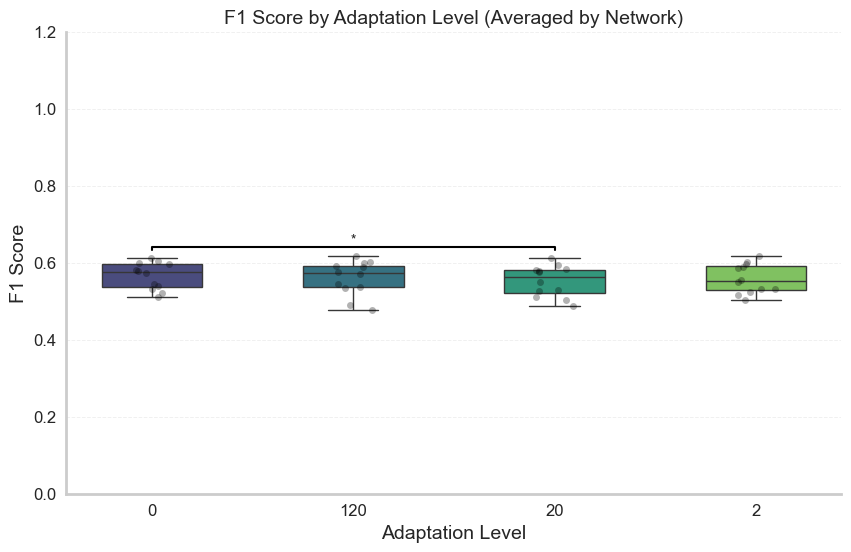

In [12]:
def plot_f1_boxplot_by_adapt(df, metric="F1", aggregate_by_network=False):
    # Define specific order
    desired_order = [0, 120, 20, 2]
    # Filter to only include values present in the dataframe
    adapt_values = [a for a in desired_order if a in df["Adapt"].unique()]
    
    # Data preparation
    if aggregate_by_network:
        # Average over sessions/channels for each network
        plot_df = df.groupby(["Network", "Adapt"])[metric].median().reset_index()
        title_suffix = " (Averaged by Network)"
        print(f"Aggregated by network. N={len(plot_df['Network'].unique())} networks.")
    else:
        plot_df = df
        title_suffix = ""

    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Boxplot
    sns.boxplot(x="Adapt", y=metric, data=plot_df, ax=ax, palette="viridis", width=0.5, showfliers=False, order=adapt_values)
    sns.stripplot(x="Adapt", y=metric, data=plot_df, ax=ax, color="black", alpha=0.3, jitter=True, order=adapt_values)
    
    # Statistical annotation (Wilcoxon)
    if aggregate_by_network:
        pivot_cols = ["Network"]
    else:
        pivot_cols = ["Session", "Channel", "Network"]
        
    pivot = plot_df.pivot_table(index=pivot_cols, columns="Adapt", values=metric)
    pivot = pivot.dropna()
    print(f"N={len(pivot)} matched samples for statistics.")
    
    if len(pivot) > 0:
        centers = range(len(adapt_values))
        # Calculate max height for annotations
        max_val = plot_df[metric].max()
        
        combinations = list(itertools.combinations(range(len(adapt_values)), 2))
        for idx, (i, j) in enumerate(combinations):
            a1 = adapt_values[i]
            a2 = adapt_values[j]
            
            v1 = pivot[a1].values
            v2 = pivot[a2].values
            
            # Check if we have enough samples for Wilcoxon
            if len(v1) >= 3:
                stat, p = wilcoxon(v1, v2)
                
                # Stacking logic for brackets
                h = max_val + 0.05 * (1 + idx) * (max_val * 0.1)
                
                if p < 0.05:
                    print(f"{a1} vs {a2}: p={p:.4f}")
                    barplot_annotate_brackets(i, j, p, centers, [h]*len(centers), ax)
            else:
                print(f"Skipping stats for {a1} vs {a2}: N={len(v1)} too small")
    
    ax.grid(True, axis='y', linestyle='--',linewidth=0.7,alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)           
    ax.set_title(f"{metric} Score by Adaptation Level{title_suffix}",fontsize=14)
    ax.set_ylim(0, 1.2) # Adjust to fit brackets
    ax.set_ylabel(f"{metric} Score",fontsize=14)
    ax.set_xlabel("Adaptation Level",fontsize=14)
    ax.tick_params(axis='both', which='major', labelsize=12)
    ax.spines['bottom'].set_linewidth(2)
    ax.spines['left'].set_linewidth(2)
    plt.show()

if 'df' in locals():
    plot_f1_boxplot_by_adapt(df, "F1", aggregate_by_network=True)

0 vs 120: p=0.7505
0 vs 20: p=0.1322
0 vs 2: p=0.6462
120 vs 20: p=0.0487
120 vs 2: p=0.6267
20 vs 2: p=0.0929


C:\Users\Pc\AppData\Local\Temp\ipykernel_30116\1802703406.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x="Adapt", y=metric, data=plot_df, ax=ax, palette=colors, inner="quartile", cut=0, order=adapt_values)
C:\Users\Pc\AppData\Local\Temp\ipykernel_30116\1802703406.py:80: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["Fixed","60", "10", "1"])


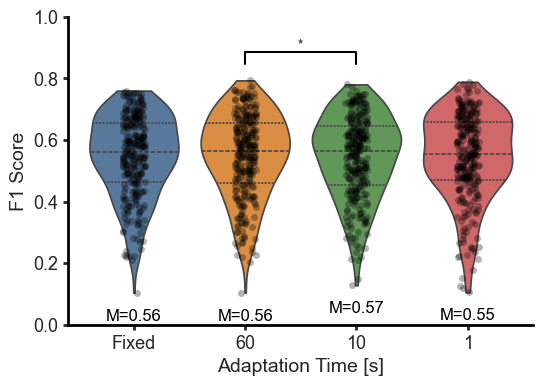

In [13]:
def plot_f1_violin_by_adapt(df, metric="F1", aggregate_by_network=False):
    # Define specific order
    desired_order = [0, 120, 20, 2]
    # Filter to only include values present in the dataframe
    adapt_values = [a for a in desired_order if a in df["Adapt"].unique()]
    
    # Data preparation
    if aggregate_by_network:
        # Average over sessions/channels for each network
        plot_df = df.groupby(["Network", "Adapt"])[metric].mean().reset_index()
        title_suffix = " (Averaged by Network)"
        print(f"Aggregated by network. N={len(plot_df['Network'].unique())} networks.")
    else:
        plot_df = df
        title_suffix = ""

    fig, ax = plt.subplots(figsize=(6, 4))
    
    colors=["#4E79A7", "#F28E2B", "#59A14F", "#E15759"]

    # Violin plot
    sns.violinplot(x="Adapt", y=metric, data=plot_df, ax=ax, palette=colors, inner="quartile", cut=0, order=adapt_values)
    # Overlay points
    sns.stripplot(x="Adapt", y=metric, data=plot_df, ax=ax, color="black", alpha=0.3, jitter=True, order=adapt_values)
    
    # Statistical annotation (Wilcoxon)
    if aggregate_by_network:
        pivot_cols = ["Network"]
    else:
        pivot_cols = ["Session", "Channel", "Network"]
        
    pivot = plot_df.pivot_table(index=pivot_cols, columns="Adapt", values=metric)
    # display(pivot.head())
    pivot = pivot.dropna()

    # Annotate medians and N
    medians = plot_df.groupby('Adapt')[metric].median()
    counts = plot_df.groupby('Adapt')[metric].count()
    mins=plot_df.groupby('Adapt')[metric].min() 
        
    for i, adapt in enumerate(desired_order):
        if adapt in medians:
            val = medians[adapt]
            min_val = mins[adapt]
            ax.text(i, min_val- 0.1, f'M={val:.2f}',  
            ha='center', va='bottom', fontsize=12, color='black')

    if len(pivot) > 0:
        centers = range(len(adapt_values))
        max_val = plot_df[metric].max()
        
        combinations = list(itertools.combinations(range(len(adapt_values)), 2))
        for idx, (i, j) in enumerate(combinations):
            a1 = adapt_values[i]
            a2 = adapt_values[j]
            
            v1 = pivot[a1].values
            v2 = pivot[a2].values
            
            # Check if we have enough samples for Wilcoxon
            if len(v1) >= 3: 
                stat, p = wilcoxon(v1, v2)
                
                # Stacking logic for brackets
                h = max_val + 0.05 * (1 + idx) * (max_val * 0.1)
                
                print(f"{a1} vs {a2}: p={p:.4f}")
                barplot_annotate_brackets(i, j, p, centers, [h]*len(centers), ax)
            else:
                print(f"Skipping stats for {a1} vs {a2}: N={len(v1)} too small")
                
    # ax.set_title(f"{metric} Distribution by Adaptation Level{title_suffix}")
    ax.set_ylim(0,1) 

    ax.grid(False)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines[['bottom','left']].set_linewidth(1.3)
    ax.spines[['bottom','left']].set_color('black')
    ax.set_xticklabels(["Fixed","60", "10", "1"])
    ax.tick_params(axis='both', which='major', labelsize=13, bottom=True, left=True,width=2)
    ax.tick_params(axis='x', rotation=0)

    ax.set_ylabel(f"{metric} Score",fontsize=14)
    ax.set_xlabel("Adaptation Time [s]",fontsize=14)
    ax.tick_params(axis='both', which='major', labelsize=13)
    ax.spines['bottom'].set_linewidth(2)
    ax.spines['left'].set_linewidth(2)
    plt.show()
    return fig,ax

if 'df' in locals():
    fig,ax=plot_f1_violin_by_adapt(df, "F1", aggregate_by_network=False)
    os.makedirs("figures", exist_ok=True)
    # fig.savefig("figures/f1_violin_by_adapt.svg", dpi=300, bbox_inches='tight')
    # fig.savefig("figures/f1_violin_by_adapt.png",dpi=300)

C:\Users\Pc\AppData\Local\Temp\ipykernel_30116\427118391.py:58: RuntimeWarning: divide by zero encountered in divide
  y = (f1 * x) / (2 * x - f1)


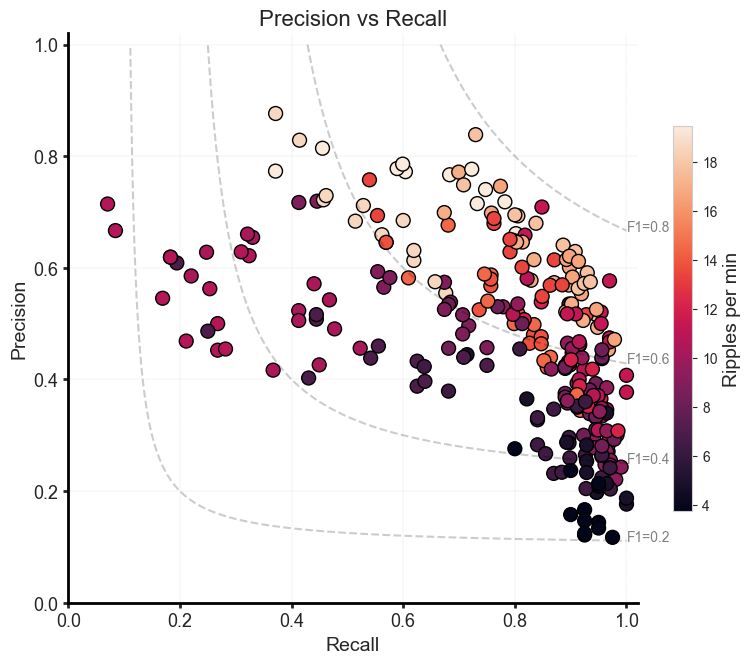

In [14]:
import numpy as np
import matplotlib.pyplot as plt

def plot_precision_recall(df, average_by_network=False, average_by_session=False):
    fig, ax = plt.subplots(figsize=(8,8))

    desired_order = [0, 120, 20, 2]
    adapt_values = [a for a in desired_order if a in df["Adapt"].unique()]
    adapt_values = [20]

    # Collect all values for global color scaling
    all_rpm = []

    for adapt in adapt_values:
        subset = df[df["Adapt"] == adapt]

        if average_by_network:
            subset = subset.groupby("Network")[["Precision", "Recall", "Ripples_per_min"]].median().reset_index()
        elif average_by_session:
            subset = subset.groupby("Session")[["Precision", "Recall", "Ripples_per_min"]].median().reset_index()

        all_rpm.extend(subset["Ripples_per_min"].values)

    # --- Normalize colormap across all points ---
    vmin = np.min(all_rpm)
    vmax = np.max(all_rpm)

    # Plot points
    for adapt in adapt_values:
        subset = df[df["Adapt"] == adapt]

        if average_by_network:
            subset = subset.groupby("Network")[["Precision", "Recall", "Ripples_per_min"]].median().reset_index()
        elif average_by_session:
            subset = subset.groupby("Session")[["Precision", "Recall", "Ripples_per_min"]].median().reset_index()

        sc = ax.scatter(
            subset["Recall"],
            subset["Precision"],
            c=subset["Ripples_per_min"],
            # cmap="viridis",
            vmin=vmin,
            vmax=vmax,
            s=100,
            edgecolors="black",
            linewidth=1.0
        )

    # --- Add Colorbar ---
    cbar = plt.colorbar(sc, ax=ax, drawedges=False,pad=0.05,shrink=0.5)
    cbar.set_label("Ripples per min", fontsize=14)

    # --- F1 isolines ---
    f1_scores = [0.2, 0.4, 0.6, 0.8]
    x = np.linspace(0.01, 1, 10000)

    for f1 in f1_scores:
        y = (f1 * x) / (2 * x - f1)
        valid = (y >= 0) & (y <= 1)
        ax.plot(x[valid], y[valid], 'k--', alpha=0.2)
        if any(valid):
            ax.text(x[valid][-1], y[valid][-1], f"F1={f1}", color='gray')

    # --- Formatting ---
    ax.set_xlabel("Recall",fontsize=14)
    ax.set_ylabel("Precision", fontsize=14)
    ax.set_title("Precision vs Recall", fontsize=16)
    ax.set_xlim(0, 1.02)
    ax.set_ylim(0, 1.02)
    ax.set_aspect(1)

    ax.grid(True, lw=0.3, alpha=0.8, linestyle='--')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines[['bottom', 'left']].set_linewidth(2)
    ax.spines[['bottom','left']].set_color('black')

    ax.tick_params(axis='both', which='major', labelsize=13, bottom=True, left=True,width=2.0)
    ax.tick_params(axis='x', rotation=0)

    plt.tight_layout()
    plt.show()
    return fig, ax
fig,ax=plot_precision_recall(df, average_by_network=False, average_by_session=False)

C:\Users\Pc\AppData\Local\Temp\ipykernel_30116\284244858.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Adapt", y="Percent Change", data=melted, palette="coolwarm", order=adapt_values)


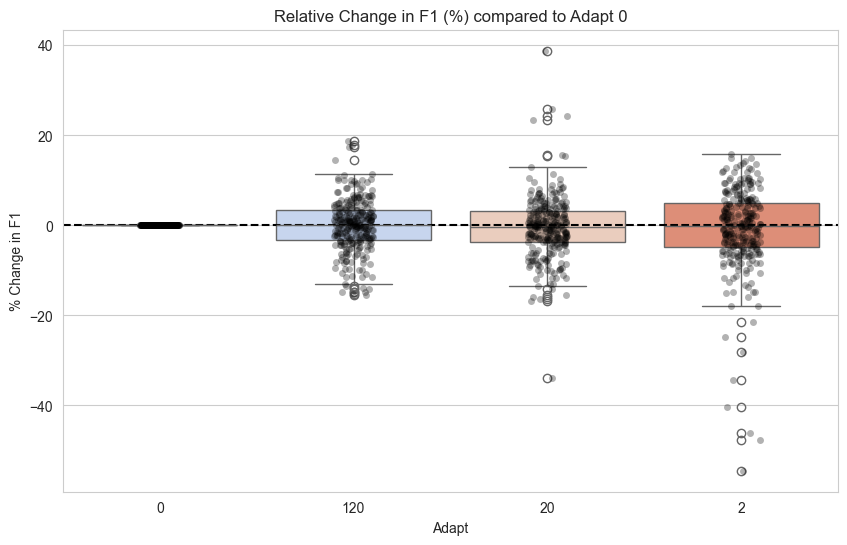

In [15]:
def plot_relative_change(df, metric="F1"):
    # Pivot to have Adapt as columns
    pivot_cols = ["Session", "Channel", "Network"]
    if "Dataset" in df.columns:
        pivot_cols.append("Dataset")
        
    pivot = df.pivot_table(index=pivot_cols, columns="Adapt", values=metric) # Pivot table
    # print(pivot.head())
    # Calculate change relative to Adapt 0 (or lowest adapt value)
     # Define specific order
    desired_order = [0, 120, 20, 2]
    # Filter to only include values present in the dataframe
    adapt_values = [a for a in desired_order if a in df["Adapt"].unique()]
    baseline_adapt = 0
    
    if baseline_adapt not in pivot.columns:
        print(f"Baseline adapt {baseline_adapt} not found in pivot columns.")
        return

    changes = pd.DataFrame()
    for col in pivot.columns:
        changes[col] = (pivot[col] - pivot[baseline_adapt]) / pivot[baseline_adapt] * 100
        
    # Melt for plotting
    melted = changes.melt(var_name="Adapt", value_name="Percent Change")
    # print(melted)
    plt.figure(figsize=(10, 6))
    sns.boxplot(x="Adapt", y="Percent Change", data=melted, palette="coolwarm", order=adapt_values)
    # Overlay points
    sns.stripplot(x="Adapt", y="Percent Change", data=melted, color="black", alpha=0.3, jitter=True, order=adapt_values)

    plt.axhline(0, color='black', linestyle='--')
    plt.title(f"Relative Change in {metric} (%) compared to Adapt {baseline_adapt}")
    plt.ylabel(f"% Change in {metric}")
    plt.show()

if 'df' in locals():
    plot_relative_change(df, "F1")

,Session,Adapt,Metric,Value
0,2025-09-22_17-42-27,20,Precision,0.532905
1,2025-09-22_17-55-26,20,Precision,0.634919
2,2025-09-23_15-50-26,20,Precision,0.621392
3,2025-09-23_16-17-52,20,Precision,0.438929
4,2025-09-24_10-24-40,20,Precision,0.551839


               0.25      0.50      0.75
Metric                                 
F1         0.443247  0.562139  0.632736
Precision  0.379260  0.499117  0.583136
Recall     0.752527  0.890110  0.924332


C:\Users\Pc\AppData\Local\Temp\ipykernel_30116\3691779514.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Metric', y='Value', data=melted, ax=ax, palette=custom_palette, inner='quartile', cut=0, order=order, alpha=1.0, linewidth=2)


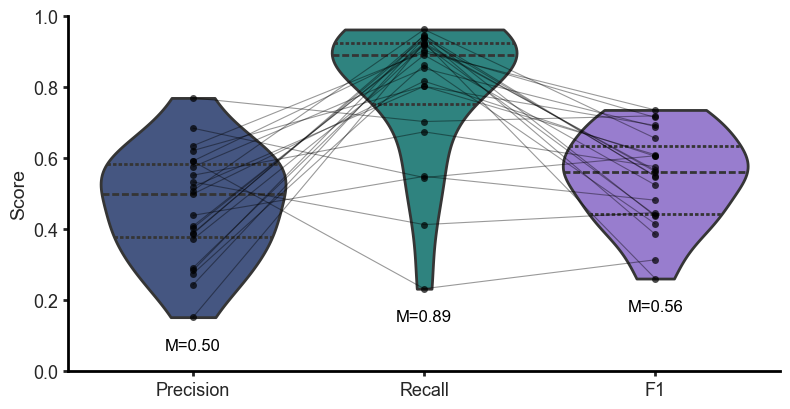

In [19]:
# Plot Precision, Recall and F1 for a single Adaptation level in the same figure
def plot_metrics_single_adapt(df, adapt=20, aggregate_by_network=False, aggregate_by_session=False,metrics=("Precision", "Recall", "F1")):
    """Plot the distributions of multiple metrics for a single `adapt` value in one plot."""
    # Ensure adapt exists in the dataframe
    if adapt not in df["Adapt"].unique():
        print(f"Adapt {adapt} not present in dataframe. Available: {sorted(df['Adapt'].unique())}")
        return

    # Prepare data for the requested adapt
    if aggregate_by_network:
        agg_cols = ['Network', 'Adapt']
        plot_df = df.groupby(agg_cols)[list(metrics)].median().reset_index()
        title_suffix = ' (Averaged by Network)'
    elif aggregate_by_session:
        agg_cols = ['Session', 'Adapt']
        plot_df = df.groupby(agg_cols)[list(metrics)].median().reset_index()
        title_suffix = ' (Averaged by Session)'
    else:
        plot_df = df.copy()
        title_suffix = ''

    plot_df = plot_df[plot_df['Adapt'] == adapt]
    if len(plot_df) == 0:
        print(f'No rows for Adapt {adapt} after filtering.')
        return

    # Melt metrics into long form for plotting
    id_vars = [c for c in ['Session', 'Channel', 'Network', 'Adapt'] if c in plot_df.columns]
    melted = plot_df.melt(id_vars=id_vars, value_vars=list(metrics), var_name='Metric', value_name='Value')
    display(melted.head())
    # Plot
    fig, ax = plt.subplots(figsize=(8, 4.2))
    order = list(metrics)
    snn_color = "#9370DB" 
    # Create custom palette: 2 colors from viridis, then the SNN color
    viridis_colors = sns.color_palette("viridis", n_colors=3)
    custom_palette = [viridis_colors[0], viridis_colors[1], snn_color]

    sns.violinplot(x='Metric', y='Value', data=melted, ax=ax, palette=custom_palette, inner='quartile', cut=0, order=order, alpha=1.0, linewidth=2)



    # Annotate medians and N
    medians = melted.groupby('Metric')['Value'].median()
    counts = melted.groupby('Metric')['Value'].count()
    mins=melted.groupby('Metric')['Value'].min() 
    
    for i, metric in enumerate(order):
        if metric in medians:
            val = medians[metric]
            min_val = mins[metric]
            ax.text(i, min_val- 0.1, f'M={val:.2f}',  
            ha='center', va='bottom', fontsize=12, color='black')

    # if aggregate_by_session:
    #     melted = melted.groupby(['Session', 'Metric'])['Value'].median().reset_index()
    quantiles=melted.groupby('Metric')['Value'].quantile([0.25, 0.5, 0.75]).unstack()
    print(quantiles)
    sns.stripplot(x='Metric', y='Value', data=melted, ax=ax, color='k', alpha=0.7, jitter=False, order=order)
    # Plot Lines between the points from the same session/network
    group_cols = [c for c in melted.columns if c not in ['Metric', 'Value']]

    if group_cols:
        for _, grp in melted.groupby(group_cols):
            # Filter metrics present in this group that adhere to the plot order
            grp = grp.set_index('Metric')
            present_metrics = [m for m in order if m in grp.index]
            
            if len(present_metrics) > 1:
                xs = [order.index(m) for m in present_metrics]
                ys = grp.loc[present_metrics, 'Value'].values
                ax.plot(xs, ys, color='black', alpha=0.4, linewidth=0.8, zorder=3)

    ax.set_ylim(0, 1)
    # ax.set_title(f'Performance Metrics', fontsize=14)
    ax.set_ylabel('Score', fontsize=14)
    ax.set_xlabel('')
    # ax.set_xlabel('Metric', fontsize=14)
    # ax.grid(True, axis='y', linestyle='--', linewidth=0.6, alpha=0.4)
    ax.grid(False)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines[['bottom','left']].set_linewidth(2)
    ax.spines[['bottom','left']].set_color('black')

    ax.tick_params(axis='both', which='major', labelsize=13, bottom=True, left=True,width=2.0)
    ax.tick_params(axis='x', rotation=0)
    # ax.set_yticks(np.arange(0.3, 1.1, 0.1))
    plt.tight_layout()
    plt.show()
    return fig, ax

if 'df' in locals():
    fig,ax=plot_metrics_single_adapt(df, adapt=20, aggregate_by_network=False,aggregate_by_session=True)
    # plot_f1_violin_by_adapt(df, "F1", aggregate_by_network=False)
    fig.savefig("figures/metrics_single_adapt.svg", format="svg")
    fig.savefig("figures/metrics_single_adapt.png", format="png", dpi=300)

Pearson correlation: r=0.813, p=2.420e-06
Spearman correlation: r=0.850, p=2.878e-07
Linear regression: slope=0.024, r=0.813, p=2.420e-06


C:\Users\Pc\AppData\Local\Temp\ipykernel_30116\3873792107.py:71: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')


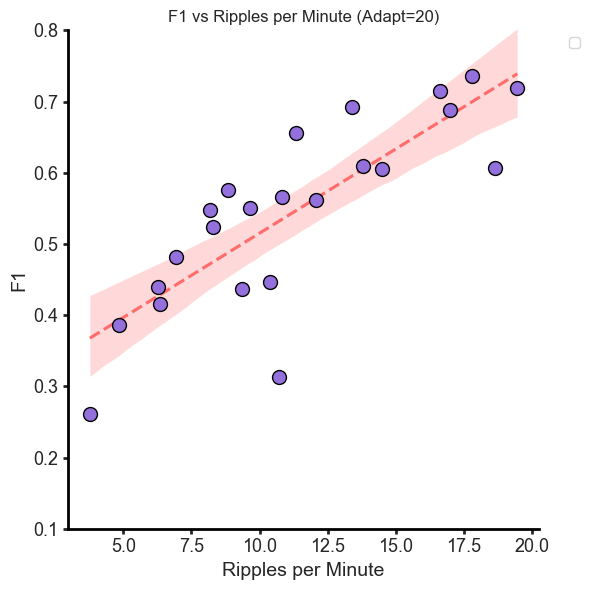

In [17]:
#plot ripple per min vs F1 for a single adapt...
from scipy.stats import pearsonr, spearmanr,linregress
def scatter_ripples_per_min_vs_metric(df,metric="F1", adapt=20,aggregate_by_network=False, aggregate_by_session=False):
    subset = df[df["Adapt"] == adapt]

    # new_sessions=   {"Calb_251209_160255",
    # "Calb_251210_115904",
    # "Calb_251210_121141",
    # "Calb_251210_122327",
    # "Calb_251210_162849",
    # "Calb_251210_164150",
    # "Calb_251210_165332",
    # "Calb_251211_104316",
    # "Calb_251211_105518",
    # "Calb_251211_110650"
    # }
    new_sessions=set(lists_sessions.HFO_sessions)

    if aggregate_by_network:
        subset = subset.groupby("Network")[["Ripples_per_min", metric]].median().reset_index()
    if aggregate_by_session:
        subset = subset.groupby("Session")[["Ripples_per_min", metric]].median().reset_index()

    subset["Hue"] = subset["Session"].apply(lambda x: "New" if x in new_sessions else "Old")
    viridis_colors = sns.color_palette("viridis", n_colors=3)
    snn_color = "#9370DB" 

    color_metric={"Precision": viridis_colors[0], "Recall": viridis_colors[1], "F1": snn_color}
    fig,ax=plt.subplots(figsize=(6, 6))
    sns.scatterplot(x="Ripples_per_min", y=metric, data=subset,  
                    color=color_metric[metric],
                    # hue="Hue",
                    # palette={"New": "#E15759", "Old": "#4E79A7"}, 
                    s=100,ax=ax, 
                    legend=False, 
                    edgecolors="black", 
                    linewidth=1.0,zorder=3)


   
         # helper for regression
    def plot_regression(data, color, label):
        x = data["Ripples_per_min"]
        y = data[metric]
        if len(x) > 1:
            slope, intercept, r_value, p_value, std_err = linregress(x, y)

            # Plot line
            sns.regplot(x="Ripples_per_min", y=metric, data=data, scatter=False, 
                        color=color, ax=ax, line_kws={"linestyle": "--", "alpha": 0.5})
            return slope, r_value, p_value
        return None, None, None

    # calculate correlation
    if len(subset) > 1:
        pearson_corr, pearson_p = pearsonr(subset["Ripples_per_min"], subset[metric])
        spearman_corr, spearman_p = spearmanr(subset["Ripples_per_min"], subset[metric])
        print(f"Pearson correlation: r={pearson_corr:.3f}, p={pearson_p:.3e}")
        print(f"Spearman correlation: r={spearman_corr:.3f}, p={spearman_p:.3e}")


    # Plot trendline
    # Fit a linear regression line
    slope, r_value, p_value = plot_regression(subset, color="red", label="All Data")    
    print(f"Linear regression: slope={slope:.3f}, r={r_value:.3f}, p={p_value:.3e}")
    
    ax.set_aspect('auto')
    ax.set_xlabel("Ripples per Minute",fontsize=14)
    ax.set_ylabel(metric, fontsize=14)
    ax.set_title(f"{metric} vs Ripples per Minute (Adapt={adapt})")
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    # ax.grid(True)
 
    ax.grid(False)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines[['bottom','left']].set_linewidth(2)
    ax.spines[['bottom','left']].set_color('black')
    ax.tick_params(axis='both', which='major', labelsize=13, bottom=True, left=True,width=2.0)
    ax.tick_params(axis='x', rotation=0)
    ax.set_ylim(0.1, 0.8)

    
    plt.tight_layout()
    plt.show()
    return fig
aggregate_by_network=False 
aggregate_by_session=True
fig=scatter_ripples_per_min_vs_metric(df,metric="F1", adapt=20, aggregate_by_network=aggregate_by_network, aggregate_by_session=aggregate_by_session) 
# fig.savefig("figures/f1_vs_ripples_per_min.svg", format="svg",dpi=500)
# fig=scatter_ripples_per_min_vs_metric(df,metric="Precision", adapt=20, aggregate_by_network=aggregate_by_network, aggregate_by_session=aggregate_by_session) 
# fig.savefig("figures/precision_vs_ripples_per_min.svg", format="svg",dpi=500)
# fig=scatter_ripples_per_min_vs_metric(df,metric="Recall", adapt=20, aggregate_by_network=aggregate_by_network, aggregate_by_session=aggregate_by_session)
# fig.savefig("figures/recall_vs_ripples_per_min.svg", format="svg",dpi=500)


Precision - Pearson: r=0.873, p=5.307e-08 | Spearman: r=0.850
Precision - Linear Reg: slope=0.030, r=0.873, p=5.307e-08
Recall - Pearson: r=-0.154, p=4.841e-01 | Spearman: r=-0.324
Recall - Linear Reg: slope=-0.007, r=-0.154, p=4.841e-01
F1 - Pearson: r=0.813, p=2.420e-06 | Spearman: r=0.850
F1 - Linear Reg: slope=0.024, r=0.813, p=2.420e-06


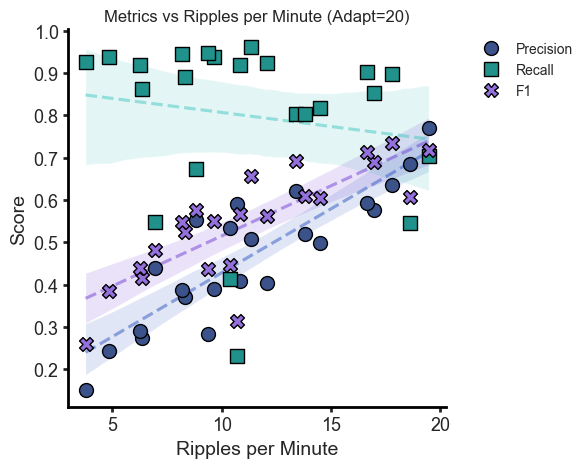

In [18]:
from scipy.stats import pearsonr, spearmanr, linregress
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
def forceAspect(ax, aspect=1):
    images = ax.get_images()
    if images:
        extent = images[0].get_extent()
        ax.set_aspect(abs((extent[1] - extent[0]) / (extent[3] - extent[2])) / aspect)
        return
    x0, x1 = ax.get_xlim()
    y0, y1 = ax.get_ylim()
    if (x1 - x0) != 0 and (y1 - y0) != 0:
        ax.set_aspect(abs((x1 - x0) / (y1 - y0)) / aspect)

def scatter_ripples_per_min_vs_all_metrics(df, metrics=["Precision", "Recall", "F1"], adapt=20, aggregate_by_network=False, aggregate_by_session=False):
    subset = df[df["Adapt"] == adapt]

    new_sessions = set(lists_sessions.HFO_sessions)
    keep_vars = ["Ripples_per_min"] + list(metrics)

    if aggregate_by_network:
        subset = subset.groupby("Network")[keep_vars].median().reset_index()
    if aggregate_by_session:
        subset = subset.groupby("Session")[keep_vars].median().reset_index()

    # subset["Hue"] = subset["Session"].apply(lambda x: "New" if x in new_sessions else "Old")
    
    # Colors
    viridis_colors = sns.color_palette("viridis", n_colors=3)
    snn_color = "#9370DB" 
    color_metric = {"Precision": viridis_colors[0], "Recall": viridis_colors[1], "F1": snn_color}
    colors_lines = {"Precision": "#315ac2", "Recall": "#45c8c0", "F1": "#7241D6"}
    
    # Markers for each metric
    marker_map = {"Precision": "o", "Recall": "s", "F1": "X"}

    fig, ax = plt.subplots(figsize=(6, 6))

    # Helper for regression
    def plot_regression(data, y_var, color, label):
        x = data["Ripples_per_min"]
        y = data[y_var]
        if len(x) > 1:
            slope, intercept, r_value, p_value, std_err = linregress(x, y)
            # Plot line
            sns.regplot(x="Ripples_per_min", y=y_var, data=data, scatter=False, 
                        color=color, ax=ax, label=label, line_kws={"linestyle": "--", "alpha": 0.5})
            return slope, r_value, p_value
        return None, None, None

    for metric in metrics:
        # 1. Scatter Plot
        # Use 'marker' (singular) to set the shape for this specific call
        sns.scatterplot(
            x="Ripples_per_min", 
            y=metric, 
            data=subset,  
            color=color_metric[metric],
            s=100,
            ax=ax, 
            legend=False, 
            edgecolors="black", 
            linewidth=1.0,
            zorder=3,
            marker=marker_map[metric] 
        )

        # 2. Stats
        if len(subset) > 1:
            pearson_corr, pearson_p = pearsonr(subset["Ripples_per_min"], subset[metric])
            spearman_corr, spearman_p = spearmanr(subset["Ripples_per_min"], subset[metric])
            print(f"{metric} - Pearson: r={pearson_corr:.3f}, p={pearson_p:.3e} | Spearman: r={spearman_corr:.3f}")

        # 3. Regression Line
        # Pass 'metric' explicitly as the y_var
        slope, r_value, p_value = plot_regression(subset, y_var=metric, color=colors_lines[metric], label=metric)    
        
        if slope is not None:
             print(f"{metric} - Linear Reg: slope={slope:.3f}, r={r_value:.3f}, p={p_value:.3e}")

    ax.set_aspect('auto')
    ax.set_xlabel("Ripples per Minute", fontsize=14)
    ax.set_ylabel("Score", fontsize=14) # Changed from 'metric' to generic 'Score'
    ax.set_title(f"Metrics vs Ripples per Minute (Adapt={adapt})")
    
    # Custom Legend to show markers
    legend_handles = []
    for metric in metrics:
        # Create a proxy artist for the legend
        handle = plt.Line2D([0], [0], marker=marker_map[metric], color='w', label=metric,
                          markerfacecolor=color_metric[metric], markersize=10, 
                          markeredgecolor='k')
        legend_handles.append(handle)

    ax.legend(handles=legend_handles, bbox_to_anchor=(1.05, 1), loc='upper left', frameon=False)
    
    ax.grid(False)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines[['bottom','left']].set_linewidth(2)
    ax.spines[['bottom','left']].set_color('black')
    ax.tick_params(axis='both', which='major', labelsize=13, bottom=True, left=True, width=2.0)
    # plt.gca().set_aspect('equal')
    # Depending on your data, you might want to force the y-limit
    # ax.set_ylim(0, 1.05)
    forceAspect(ax,aspect=1)
    plt.tight_layout()
    plt.show()
    return fig

aggregate_by_network = False
aggregate_by_session = True
fig = scatter_ripples_per_min_vs_all_metrics(df, metrics=["Precision", "Recall", "F1"], adapt=20, aggregate_by_network=aggregate_by_network, aggregate_by_session=aggregate_by_session) 
fig.savefig("figures/metrics_vs_ripples_per_min.svg", format="svg", dpi=500)